# 04 — Homoclinic Orbits

Construct the analytical Duffing sech homoclinic and the numerical Bessel homoclinic; compare them; quantify the Duffing-validity boundary.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

use_paper_style()


In [2]:
from steering.analysis.homoclinic import numerical_homoclinic
bessel = BesselSteeringModel()
p = ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.4)
c1, c3 = bessel.taylor_coefficients(p)
duff = DuffingModel(c1=c1, c3=c3)
print(f'c1={c1:.3f}, c3={c3:.3f}, theta_max(Duffing)={(2*c1/abs(c3))**0.5:.3f}')


c1=21.898, c3=-34.093, theta_max(Duffing)=1.133


## Analytical Duffing homoclinic

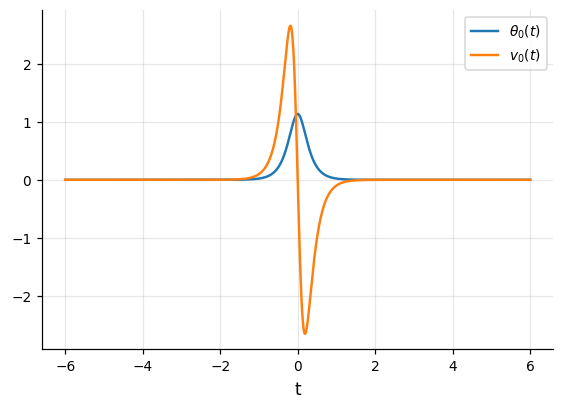

In [10]:
t = np.linspace(-6, 6, 1201)
th_d, v_d = duff.homoclinic_orbit(t)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, th_d, label=r'$\theta_0(t)$')
ax.plot(t, v_d, label=r'$v_0(t)$')
ax.legend(); ax.set_xlabel('t'); plt.show()


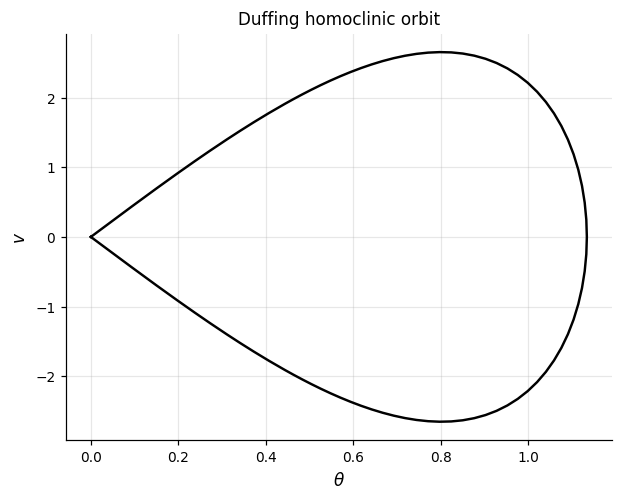

In [7]:
plt.plot(th_d, v_d, 'k-'); plt.xlabel(r'$\theta$'); plt.ylabel(r'$v$'); plt.title('Duffing homoclinic orbit'); plt.show()

## Numerical Bessel homoclinic (apex-mirror method)

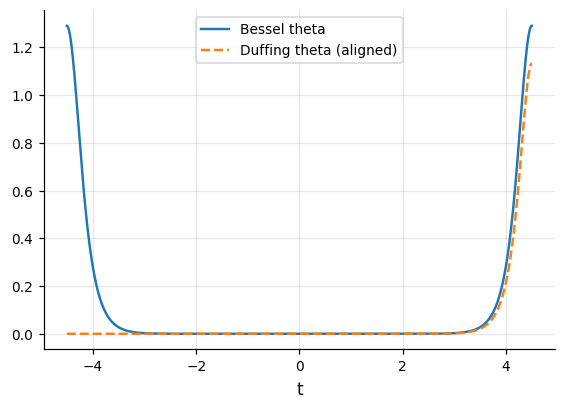

In [31]:
t_b, th_b, v_b = numerical_homoclinic(bessel, p)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_b, th_b, label='Bessel theta')
t_apex_b = t_b[-1]
th_d2, _ = duff.homoclinic_orbit(t_b - t_apex_b)
ax.plot(t_b, th_d2, label='Duffing theta (aligned)', ls='--')
# t_d, th_d, v_d = numerical_homoclinic(duff, p)
# ax.plot(t_d, th_d, label='Duffing theta', ls='--')
ax.legend(); ax.set_xlabel('t'); plt.show()


## Pointwise error along the orbit

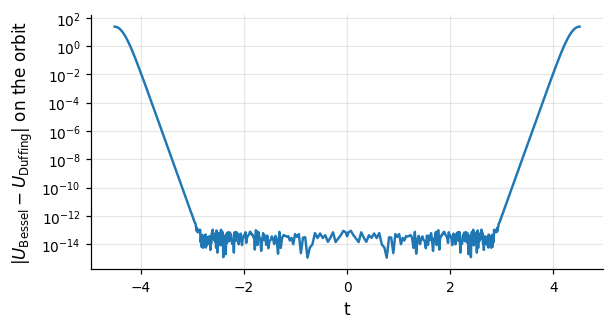

In [32]:
U_b = np.asarray(bessel.steering_drive(th_b, p))
U_d = duff.steering_drive(th_b)
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(t_b, np.abs(U_b - U_d) + 1e-15)
ax.set_xlabel('t')
ax.set_ylabel(r'$|U_{\mathrm{Bessel}} - U_{\mathrm{Duffing}}|$ on the orbit')
plt.show()


## Validity boundary: relative L^2 error vs $\theta_{\max}/\pi$

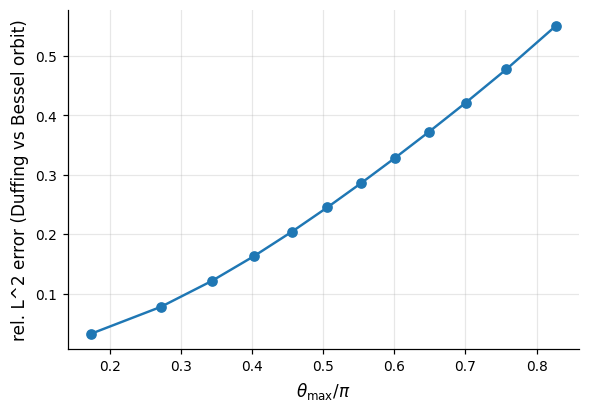

In [34]:
from scipy.integrate import simpson
deltas = np.linspace(1.34, 1.55, 12)
errs, tmaxes = [], []
for d in deltas:
    pp = p.replace(delta=d)
    c1d, c3d = bessel.taylor_coefficients(pp)
    if not (c1d > 0 and c3d < 0):
        continue
    duf = DuffingModel(c1=c1d, c3=c3d)
    t_n, th_n, _ = numerical_homoclinic(bessel, pp, t_max = 100)
    t_apex_n = t_n[-1] # The midpoint of your concatenated full array
    th_anal, _ = duf.homoclinic_orbit(t_n - t_apex_n) # Shift the time array to align the apex with t=0
    # t_anal, th_anal, _ = numerical_homoclinic(duf, pp, t_max = 100)
    num = simpson((th_n[len(th_n)//2:] - th_anal[len(th_anal)//2:])**2, x=t_n[len(t_n)//2:])
    den = simpson(th_n[len(th_n)//2:]**2, x=t_n[len(t_n)//2:])
    errs.append(np.sqrt(num/den))
    tmaxes.append(np.max(np.abs(th_n)) / np.pi)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tmaxes, errs, 'o-')
ax.set_xlabel(r'$\theta_{\max}/\pi$')
ax.set_ylabel(r'rel. L^2 error (Duffing vs Bessel orbit)')
plt.show()
